# 📘 Notebook 1: Text Processing & Tokenization
## Building LLMs from Scratch Workshop

**Objective:** Understand how raw text becomes numerical input for a language model.

**What you'll learn:**
1. How tokenization works (character-level → BPE)
2. Building a custom vocabulary and encoder/decoder
3. Implementing Byte-Pair Encoding (BPE) from scratch
4. Creating sliding-window datasets for next-token prediction
5. Building PyTorch `Dataset` and `DataLoader` for LLM training

**Prerequisites:** Basic Python, some PyTorch familiarity

---


## 1. Setup & Imports

We only need PyTorch and standard Python libraries. No heavy frameworks!


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import re
import collections
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter, defaultdict

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# GPU vs CPU Tip:
# Tokenization is CPU-bound. GPU helps only during model training.
# All code in this notebook runs fine on CPU.


Using device: cpu
PyTorch version: 2.10.0+cpu


In [2]:
# ============================================================
# Project Directory Setup
# ============================================================
# This cell ensures all paths point to the correct directories
# regardless of where you run the notebook from.
import os

# If running from notebooks/ folder
if os.path.basename(os.getcwd()) == 'notebooks':
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

# Create directories if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Results dir:  {RESULTS_DIR}")


Project root: d:\Documents\Unisole\UniTransformerWorkshop
Data dir:     d:\Documents\Unisole\UniTransformerWorkshop\data
Models dir:   d:\Documents\Unisole\UniTransformerWorkshop\models
Results dir:  d:\Documents\Unisole\UniTransformerWorkshop\results


## 2. Loading Text Data

We'll create a **synthetic mini-dataset** so this notebook runs anywhere without downloads.
We also show how to load real datasets.

### 2.1 Synthetic Training Corpus


In [5]:
# --- Synthetic mini-corpus for the workshop ---
# This covers diverse patterns for the tokenizer to learn

CORPUS = """The quick brown fox jumps over the lazy dog.
Machine learning is a subset of artificial intelligence.
Neural networks learn representations from data automatically.
Transformers revolutionized natural language processing in 2017.
Attention is all you need was the groundbreaking paper by Google.
Large language models can generate human-like text fluently.
GPT stands for Generative Pre-trained Transformer architecture.
Training a language model requires massive amounts of text data.
Tokenization converts raw text into numerical sequences for models.
The embedding layer maps token IDs to dense vector representations.
Self-attention allows each token to attend to all other tokens.
Multi-head attention runs multiple attention operations in parallel.
The transformer block combines attention with feed-forward networks.
Pre-training teaches the model general language understanding.
Fine-tuning adapts the pre-trained model to specific tasks.
Supervised fine-tuning uses labeled instruction-response pairs.
RLHF uses human preferences to align model outputs with values.
A reward model scores responses based on human preference data.
PPO is a policy optimization algorithm used in RLHF training.
The KL divergence penalty prevents the model from diverging too far.
Temperature controls the randomness of text generation output.
Top-k sampling limits generation to the k most likely next tokens.
Perplexity measures how well a language model predicts text.
Cross-entropy loss is the standard training objective for LLMs.
Batch size and learning rate are critical hyperparameters to tune.
Gradient clipping prevents exploding gradients during training.
Layer normalization stabilizes training of deep neural networks.
Residual connections help gradients flow through deep architectures.
The vocabulary size determines the number of unique tokens.
Byte-pair encoding is a subword tokenization algorithm.
The special tokens include padding, beginning, and end of sequence.
Positional encoding tells the model about token order in sequence.
Causal masking ensures the model only looks at previous tokens.
The softmax function converts logits into probability distributions.
Greedy decoding always picks the most probable next token.
Beam search explores multiple generation paths simultaneously.
The context window limits how many tokens the model can process.
Scaling laws predict model performance based on size and data.
Emergent abilities appear in sufficiently large language models.
Transfer learning leverages knowledge from pre-training tasks.
"""

print(f"Corpus length: {len(CORPUS)} characters")
print(f"Corpus lines: {len(CORPUS.strip().split(chr(10)))}")
print(f"\nFirst 200 characters:")
print(CORPUS[:200])


Corpus length: 2552 characters
Corpus lines: 40

First 200 characters:
The quick brown fox jumps over the lazy dog.
Machine learning is a subset of artificial intelligence.
Neural networks learn representations from data automatically.
Transformers revolutionized natural


### 2.2 Loading Real Datasets (Optional)

For a real workshop, you might want larger datasets:


In [6]:
# --- Option A: Load from a text file ---
def load_text_file(filepath):
    """Load text from a .txt file."""
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read()

# --- Option B: Load from HuggingFace (optional) ---
# Uncomment if you want to use a real dataset:
# from datasets import load_dataset
# dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
# real_corpus = "\n".join(dataset["text"][:1000])

# For this workshop, we use our synthetic corpus
text = CORPUS
print(f"Working with {len(text)} characters of text")


Working with 2552 characters of text


In [9]:
f = load_text_file(r"D:\\Documents\\Unisole\\UniTransformerWorkshop\\data\\corpus_jngec_hp.txt")
len(f)


25714

## 3. Character-Level Tokenization

The simplest tokenization: each character is a token.

**Pros:** Tiny vocabulary, handles any text
**Cons:** Very long sequences, hard for models to learn word-level patterns


In [10]:
class CharTokenizer:
    """
    Character-level tokenizer.
    Maps each unique character to an integer ID.
    """
    def __init__(self):
        self.char_to_id = {}
        self.id_to_char = {}
        self.vocab_size = 0
    
    def build_vocab(self, text):
        """Build vocabulary from text."""
        # Get unique characters, sorted for reproducibility
        chars = sorted(set(text))
        
        # Add special tokens first
        special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
        all_tokens = special_tokens + chars
        
        self.char_to_id = {ch: i for i, ch in enumerate(all_tokens)}
        self.id_to_char = {i: ch for ch, i in self.char_to_id.items()}
        self.vocab_size = len(all_tokens)
        
        print(f"Vocabulary size: {self.vocab_size}")
        print(f"Special tokens: {special_tokens}")
        print(f"Sample mappings: 'a'→{self.char_to_id.get('a')}, "
              f"'T'→{self.char_to_id.get('T')}, ' '→{self.char_to_id.get(' ')}")
    
    def encode(self, text):
        """Convert text to list of token IDs."""
        unk_id = self.char_to_id['<UNK>']
        return [self.char_to_id.get(ch, unk_id) for ch in text]
    
    def decode(self, ids):
        """Convert list of token IDs back to text."""
        return ''.join(self.id_to_char.get(i, '<UNK>') for i in ids)

# Build and test
char_tokenizer = CharTokenizer()
char_tokenizer.build_vocab(f)

# Encode a sample
sample = "Hello, World!"
encoded = char_tokenizer.encode(sample)
decoded = char_tokenizer.decode(encoded)

print(f"\nOriginal:  '{sample}'")
print(f"Encoded:   {encoded}")
print(f"Decoded:   '{decoded}'")
print(f"Roundtrip: {sample == decoded}")


Vocabulary size: 68
Special tokens: ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
Sample mappings: 'a'→42, 'T'→37, ' '→5

Original:  'Hello, World!'
Encoded:   [26, 46, 53, 53, 56, 7, 5, 40, 56, 59, 53, 45, 1]
Decoded:   'Hello, World<UNK>'
Roundtrip: False


## 4. Word-Level Tokenization

Split text into words. Better semantic units, but large vocabulary and can't handle unknown words well.


In [11]:
class WordTokenizer:
    """
    Word-level tokenizer with basic regex splitting.
    Handles punctuation as separate tokens.
    """
    def __init__(self):
        self.word_to_id = {}
        self.id_to_word = {}
        self.vocab_size = 0
        # Pattern: split on whitespace and separate punctuation
        self.pattern = re.compile(r"""'s|'t|'re|'ve|'m|'ll|'d| ?\w+| ?[^\s\w]+|\s+""")
    
    def _tokenize(self, text):
        """Split text into word tokens."""
        return [match.strip() for match in self.pattern.findall(text) if match.strip()]
    
    def build_vocab(self, text):
        """Build vocabulary from text."""
        tokens = self._tokenize(text)
        unique_tokens = sorted(set(tokens))
        
        special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']
        all_tokens = special_tokens + unique_tokens
        
        self.word_to_id = {w: i for i, w in enumerate(all_tokens)}
        self.id_to_word = {i: w for w, i in self.word_to_id.items()}
        self.vocab_size = len(all_tokens)
        
        print(f"Vocabulary size: {self.vocab_size}")
        print(f"Sample words: {unique_tokens[:10]}")
    
    def encode(self, text):
        """Convert text to token IDs."""
        tokens = self._tokenize(text)
        unk_id = self.word_to_id['<UNK>']
        return [self.word_to_id.get(t, unk_id) for t in tokens]
    
    def decode(self, ids):
        """Convert token IDs back to text."""
        words = [self.id_to_word.get(i, '<UNK>') for i in ids]
        return ' '.join(words)

# Build and test
word_tokenizer = WordTokenizer()
word_tokenizer.build_vocab(f)

sample = "Neural networks learn from data."
encoded = word_tokenizer.encode(sample)
decoded = word_tokenizer.decode(encoded)

print(f"\nOriginal: '{sample}'")
print(f"Tokens:   {[word_tokenizer.id_to_word[i] for i in encoded]}")
print(f"IDs:      {encoded}")
print(f"Decoded:  '{decoded}'")


Vocabulary size: 1349
Sample words: ["'s", ',', '-', '.', '13th', '150', '17th', '1956', '1971', '1986']

Original: 'Neural networks learn from data.'
Tokens:   ['<UNK>', 'networks', '<UNK>', 'from', 'data', '.']
IDs:      [1, 901, 1, 642, 483, 7]
Decoded:  '<UNK> networks <UNK> from data .'


## 5. Byte-Pair Encoding (BPE) from Scratch

BPE is the tokenization algorithm used by GPT-2/3/4. It finds the optimal subword units by iteratively merging the most frequent pairs of tokens.

### How BPE Works:
1. Start with character-level tokens (+ word boundary markers)
2. Count all adjacent token pairs
3. Merge the most frequent pair into a new token
4. Repeat for N merges (N = desired vocab size - initial vocab size)

This creates a vocabulary that balances between characters and full words.


In [12]:
class BPETokenizer:
    """
    Byte-Pair Encoding tokenizer built from scratch.
    
    This implements the core BPE algorithm:
    1. Start with character-level tokens
    2. Iteratively merge most frequent pairs
    3. Build a merge table for encoding new text
    """
    
    def __init__(self, num_merges=100):
        self.num_merges = num_merges
        self.merges = {}           # (token_a, token_b) -> merged_token
        self.vocab = {}            # token -> id
        self.inverse_vocab = {}    # id -> token
        self.special_tokens = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}
    
    def _get_word_freqs(self, text):
        """
        Split text into words and count frequencies.
        Each word is represented as a tuple of characters + end-of-word marker.
        """
        words = re.findall(r'\S+', text.lower())
        word_freqs = Counter(words)
        
        # Convert each word to a tuple of characters + '</w>' marker
        # The </w> marker indicates word boundaries
        split_words = {}
        for word, freq in word_freqs.items():
            # e.g., "hello" -> ('h', 'e', 'l', 'l', 'o', '</w>')
            split_words[tuple(list(word) + ['</w>'])] = freq
        
        return split_words
    
    def _get_pair_counts(self, word_freqs):
        """Count frequency of all adjacent pairs across the vocabulary."""
        pairs = Counter()
        for word_tokens, freq in word_freqs.items():
            for i in range(len(word_tokens) - 1):
                pair = (word_tokens[i], word_tokens[i + 1])
                pairs[pair] += freq
        return pairs
    
    def _merge_pair(self, word_freqs, pair_to_merge):
        """Merge all occurrences of a pair in the vocabulary."""
        merged = pair_to_merge[0] + pair_to_merge[1]
        new_word_freqs = {}
        
        for word_tokens, freq in word_freqs.items():
            new_tokens = []
            i = 0
            while i < len(word_tokens):
                # Check if current position matches the pair
                if (i < len(word_tokens) - 1 and 
                    word_tokens[i] == pair_to_merge[0] and 
                    word_tokens[i + 1] == pair_to_merge[1]):
                    new_tokens.append(merged)
                    i += 2  # Skip both tokens
                else:
                    new_tokens.append(word_tokens[i])
                    i += 1
            new_word_freqs[tuple(new_tokens)] = freq
        
        return new_word_freqs
    
    def train(self, text):
        """
        Train BPE on the given text.
        
        Steps:
        1. Split text into words, count frequencies
        2. Start with character vocabulary
        3. Iteratively merge most frequent pairs
        """
        print(f"Training BPE with {self.num_merges} merges...")
        
        # Step 1: Get word frequencies
        word_freqs = self._get_word_freqs(text)
        
        # Step 2: Build initial character vocabulary
        initial_chars = set()
        for word_tokens in word_freqs.keys():
            for token in word_tokens:
                initial_chars.add(token)
        
        print(f"Initial character vocab size: {len(initial_chars)}")
        
        # Step 3: Iteratively merge most frequent pairs
        merge_log = []
        for i in range(self.num_merges):
            pair_counts = self._get_pair_counts(word_freqs)
            
            if not pair_counts:
                print(f"No more pairs to merge at step {i}")
                break
            
            # Find most frequent pair
            best_pair = pair_counts.most_common(1)[0]
            pair, count = best_pair
            
            if count < 2:  # Stop if no pair appears more than once
                print(f"Stopping at step {i}: no pair appears > 1 time")
                break
            
            # Merge this pair
            merged_token = pair[0] + pair[1]
            self.merges[pair] = merged_token
            word_freqs = self._merge_pair(word_freqs, pair)
            
            merge_log.append((pair, merged_token, count))
            
            if (i + 1) % 20 == 0 or i < 5:
                print(f"  Merge {i+1}: {pair} → '{merged_token}' (count: {count})")
        
        # Step 4: Build final vocabulary
        # Start with special tokens
        self.vocab = dict(self.special_tokens)
        idx = len(self.special_tokens)
        
        # Add initial characters
        for ch in sorted(initial_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1
        
        # Add merged tokens
        for pair, merged in self.merges.items():
            if merged not in self.vocab:
                self.vocab[merged] = idx
                idx += 1
        
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        
        print(f"\nFinal vocabulary size: {len(self.vocab)}")
        print(f"Merges performed: {len(self.merges)}")
        
        return merge_log
    
    def _tokenize_word(self, word):
        """Apply learned BPE merges to a single word."""
        tokens = list(word) + ['</w>']
        
        # Apply merges in order they were learned
        for pair, merged in self.merges.items():
            i = 0
            while i < len(tokens) - 1:
                if tokens[i] == pair[0] and tokens[i + 1] == pair[1]:
                    tokens = tokens[:i] + [merged] + tokens[i+2:]
                else:
                    i += 1
        
        return tokens
    
    def encode(self, text):
        """Encode text into token IDs."""
        words = re.findall(r'\S+', text.lower())
        all_ids = []
        
        for word in words:
            tokens = self._tokenize_word(word)
            for token in tokens:
                if token in self.vocab:
                    all_ids.append(self.vocab[token])
                else:
                    all_ids.append(self.vocab['<UNK>'])
        
        return all_ids
    
    def decode(self, ids):
        """Decode token IDs back into text."""
        tokens = [self.inverse_vocab.get(i, '<UNK>') for i in ids]
        
        # Join tokens and handle word boundaries
        text = ''.join(tokens)
        text = text.replace('</w>', ' ')
        return text.strip()
    
    @property
    def vocab_size(self):
        return len(self.vocab)

# Train BPE tokenizer
bpe = BPETokenizer(num_merges=150)
merge_log = bpe.train(f)


Training BPE with 150 merges...
Initial character vocab size: 40
  Merge 1: ('e', '</w>') → 'e</w>' (count: 668)
  Merge 2: ('s', '</w>') → 's</w>' (count: 502)
  Merge 3: ('i', 'n') → 'in' (count: 499)
  Merge 4: ('t', 'h') → 'th' (count: 444)
  Merge 5: ('a', 'n') → 'an' (count: 399)
  Merge 20: ('al', '</w>') → 'al</w>' (count: 167)
  Merge 40: ('e', 'd</w>') → 'ed</w>' (count: 92)
  Merge 60: ('er', '</w>') → 'er</w>' (count: 57)
  Merge 80: ('in', 'c') → 'inc' (count: 40)
  Merge 100: ('i', 'l') → 'il' (count: 33)
  Merge 120: ('ar', 'e</w>') → 'are</w>' (count: 29)
  Merge 140: ('coll', 'e') → 'colle' (count: 24)

Final vocabulary size: 194
Merges performed: 150


In [13]:
# Test the BPE tokenizer
test_sentences = [
    "Neural networks learn from data.",
    "Transformers use attention mechanisms.",
    "This is a completely new sentence.",
    "Language models generate text."
]

for sent in test_sentences:
    encoded = bpe.encode(sent)
    decoded = bpe.decode(encoded)
    tokens = [bpe.inverse_vocab.get(i, '?') for i in encoded]
    
    print(f"Original:  '{sent}'")
    print(f"Tokens:    {tokens}")
    print(f"Token IDs: {encoded}")
    print(f"Decoded:   '{decoded}'")
    print()


Original:  'Neural networks learn from data.'
Tokens:    ['n', 'e', 'ur', 'al</w>', 'n', 'et', 'w', 'or', 'k', 's</w>', 'le', 'ar', 'n', '</w>', 'f', 'ro', 'm</w>', 'd', 'at', 'a', '.</w>']
Token IDs: [31, 22, 75, 63, 31, 119, 40, 60, 28, 45, 115, 58, 31, 17, 23, 68, 122, 21, 52, 18, 67]
Decoded:   'neural networks learn from data.'

Original:  'Transformers use attention mechanisms.'
Tokens:    ['t', 'r', 'an', 's', 'for', 'm', 'ers</w>', 'u', 's', 'e</w>', 'at', 't', 'ent', 'ion</w>', 'm', 'e', 'ch', 'an', 'i', 's', 'm', 's.</w>']
Token IDs: [37, 35, 48, 36, 104, 30, 166, 38, 36, 44, 52, 37, 72, 185, 30, 22, 66, 48, 26, 36, 30, 150]
Decoded:   'transformers use attention mechanisms.'

Original:  'This is a completely new sentence.'
Tokens:    ['th', 'is</w>', 'is</w>', 'a</w>', 'co', 'mp', 'le', 'te', 'l', 'y</w>', 'n', 'e', 'w', '</w>', 's', 'ent', 'enc', 'e', '.</w>']
Token IDs: [47, 105, 105, 79, 87, 101, 115, 96, 29, 71, 31, 22, 40, 17, 36, 72, 181, 22, 67]
Decoded:   'this is a 

## 6. Visualizing Tokenization

Let's visualize how BPE merges work and compare tokenizer efficiencies.


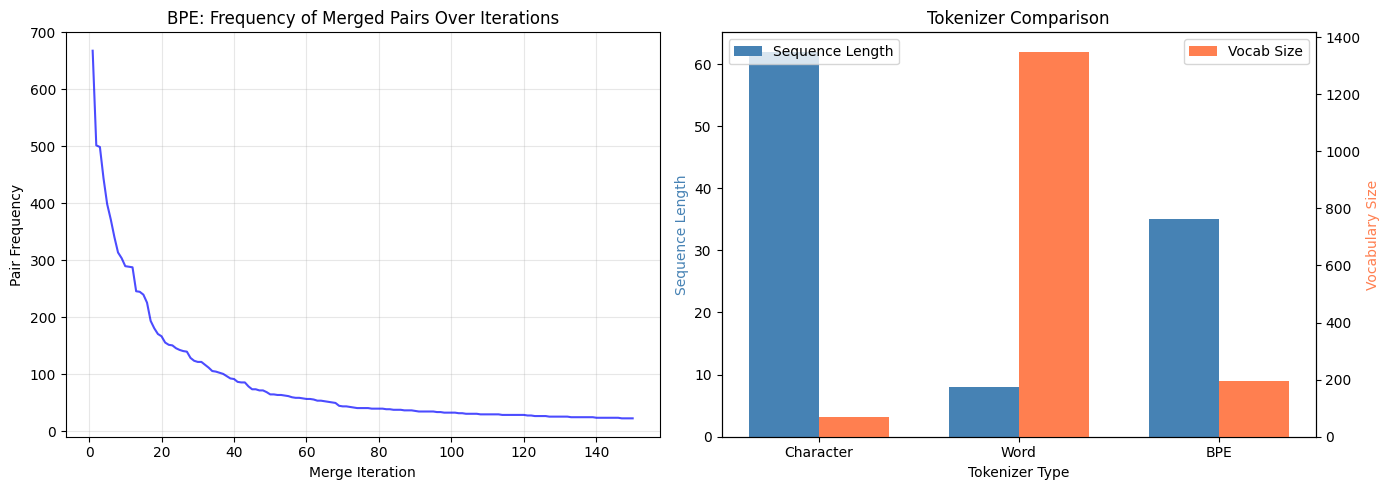


Comparison for:  Neural networks learn representations from data automatically.
  Character   :  62 tokens, vocab size = 68
  Word        :   8 tokens, vocab size = 1349
  BPE         :  35 tokens, vocab size = 194


In [14]:
# Plot: BPE merge frequency over iterations
if merge_log:
    iterations = list(range(1, len(merge_log) + 1))
    counts = [entry[2] for entry in merge_log]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Merge frequency
    axes[0].plot(iterations, counts, 'b-', alpha=0.7, linewidth=1.5)
    axes[0].set_xlabel('Merge Iteration')
    axes[0].set_ylabel('Pair Frequency')
    axes[0].set_title('BPE: Frequency of Merged Pairs Over Iterations')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Compare tokenizer efficiencies
    test_text = "Neural networks learn representations from data automatically."
    
    char_len = len(char_tokenizer.encode(test_text))
    word_len = len(word_tokenizer.encode(test_text))
    bpe_len = len(bpe.encode(test_text))
    
    tokenizers = ['Character', 'Word', 'BPE']
    lengths = [char_len, word_len, bpe_len]
    vocab_sizes = [char_tokenizer.vocab_size, word_tokenizer.vocab_size, bpe.vocab_size]
    
    x = np.arange(len(tokenizers))
    width = 0.35
    
    bars1 = axes[1].bar(x - width/2, lengths, width, label='Sequence Length', color='steelblue')
    ax2 = axes[1].twinx()
    bars2 = ax2.bar(x + width/2, vocab_sizes, width, label='Vocab Size', color='coral')
    
    axes[1].set_xlabel('Tokenizer Type')
    axes[1].set_ylabel('Sequence Length', color='steelblue')
    ax2.set_ylabel('Vocabulary Size', color='coral')
    axes[1].set_title('Tokenizer Comparison')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tokenizers)
    axes[1].legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\tokenizer_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\nComparison for: ", test_text)
    for name, length, vocab in zip(tokenizers, lengths, vocab_sizes):
        print(f"  {name:12s}: {length:3d} tokens, vocab size = {vocab}")


## 7. Sliding Window Dataset for Next-Token Prediction

For training an LLM, we need **(input, target)** pairs where:
- **Input:** a sequence of tokens `[t_0, t_1, ..., t_{n-1}]`
- **Target:** the same sequence shifted by one `[t_1, t_2, ..., t_n]`

We create these using a **sliding window** over the tokenized text.

```
Text:    "The cat sat on the mat"
Tokens:  [The, cat, sat, on, the, mat]

Window 1: Input=[The, cat, sat, on]  Target=[cat, sat, on, the]
Window 2: Input=[cat, sat, on, the]  Target=[sat, on, the, mat]
```


In [15]:
class LLMDataset(Dataset):
    """
    Dataset for next-token prediction using sliding windows.
    
    Args:
        token_ids: List of all token IDs from the corpus
        context_length: Number of tokens in each input sequence
        stride: How many tokens to slide the window (1 = maximum overlap)
    """
    
    def __init__(self, token_ids, context_length=64, stride=1):
        self.context_length = context_length
        self.input_ids = []
        self.target_ids = []
        
        # Create sliding windows
        for i in range(0, len(token_ids) - context_length, stride):
            input_chunk = token_ids[i : i + context_length]
            target_chunk = token_ids[i + 1 : i + context_length + 1]
            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))
        
        print(f"Created dataset with {len(self.input_ids)} samples")
        print(f"Context length: {context_length}, Stride: {stride}")
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

# Tokenize the full corpus with our BPE tokenizer
all_token_ids = bpe.encode(text)
print(f"Total tokens in corpus: {len(all_token_ids)}")
print(f"Vocabulary size: {bpe.vocab_size}")

# Create dataset with context_length=32 and stride=4
context_length = 32
stride = 4
dataset = LLMDataset(all_token_ids, context_length=context_length, stride=stride)

# Inspect a sample
sample_input, sample_target = dataset[0]
print(f"\nSample input shape:  {sample_input.shape}")
print(f"Sample target shape: {sample_target.shape}")
print(f"\nInput IDs:  {sample_input[:10].tolist()}...")
print(f"Target IDs: {sample_target[:10].tolist()}...")
print(f"\nNotice: target[i] == input[i+1] (shifted by one)")
print(f"Input[0:5]:  {sample_input[:5].tolist()}")
print(f"Target[0:5]: {sample_target[:5].tolist()}")


Total tokens in corpus: 1415
Vocabulary size: 194
Created dataset with 346 samples
Context length: 32, Stride: 4

Sample input shape:  torch.Size([32])
Sample target shape: torch.Size([32])

Input IDs:  [51, 34, 38, 74, 28, 17, 19, 68, 40, 31]...
Target IDs: [34, 38, 74, 28, 17, 19, 68, 40, 31, 17]...

Notice: target[i] == input[i+1] (shifted by one)
Input[0:5]:  [51, 34, 38, 74, 28]
Target[0:5]: [34, 38, 74, 28, 17]


## 8. PyTorch DataLoader

The `DataLoader` batches samples together and handles shuffling for training.


In [12]:
def create_dataloaders(text, tokenizer, context_length=32, stride=4, 
                        batch_size=4, train_ratio=0.9, shuffle=True):
    """
    Create train and validation DataLoaders from text.
    
    Args:
        text: Raw text corpus
        tokenizer: Tokenizer with encode() method
        context_length: Sequence length for the model
        stride: Window stride
        batch_size: Batch size for training
        train_ratio: Fraction of data for training
        shuffle: Whether to shuffle training data
    
    Returns:
        train_loader, val_loader, tokenizer
    """
    # Tokenize
    token_ids = tokenizer.encode(text)
    
    # Split into train/val
    split_idx = int(len(token_ids) * train_ratio)
    train_ids = token_ids[:split_idx]
    val_ids = token_ids[split_idx:]
    
    print(f"Total tokens: {len(token_ids)}")
    print(f"Train tokens: {len(train_ids)}")
    print(f"Val tokens:   {len(val_ids)}")
    
    # Create datasets
    train_dataset = LLMDataset(train_ids, context_length, stride)
    val_dataset = LLMDataset(val_ids, context_length, stride)
    
    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=shuffle,
        drop_last=True   # Drop incomplete last batch
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        drop_last=True
    )
    
    print(f"\nTrain batches: {len(train_loader)}")
    print(f"Val batches:   {len(val_loader)}")
    
    return train_loader, val_loader

# Create DataLoaders
train_loader, val_loader = create_dataloaders(
    text, bpe, 
    context_length=32, 
    stride=4, 
    batch_size=4
)

# Inspect a batch
for batch_input, batch_target in train_loader:
    print(f"\nBatch input shape:  {batch_input.shape}")  # [batch_size, context_length]
    print(f"Batch target shape: {batch_target.shape}")    # [batch_size, context_length]
    print(f"\nThis means: {batch_input.shape[0]} sequences, each {batch_input.shape[1]} tokens long")
    break


Total tokens: 1107
Train tokens: 996
Val tokens:   111
Created dataset with 241 samples
Context length: 32, Stride: 4
Created dataset with 20 samples
Context length: 32, Stride: 4

Train batches: 60
Val batches:   5

Batch input shape:  torch.Size([4, 32])
Batch target shape: torch.Size([4, 32])

This means: 4 sequences, each 32 tokens long


## 9. Saving the Tokenizer for Later Notebooks

We'll save our BPE tokenizer so we can reuse it in subsequent notebooks.


In [13]:
def save_tokenizer(tokenizer, filepath='tokenizer_config.json'):
    """Save tokenizer configuration to JSON."""
    config = {
        'vocab': tokenizer.vocab,
        'merges': {f"{k[0]}|||{k[1]}": v for k, v in tokenizer.merges.items()},
        'special_tokens': tokenizer.special_tokens,
        'num_merges': tokenizer.num_merges
    }
    with open(filepath, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"Tokenizer saved to {filepath}")

def load_tokenizer(filepath='tokenizer_config.json'):
    """Load tokenizer configuration from JSON."""
    with open(filepath, 'r') as f:
        config = json.load(f)
    
    tokenizer = BPETokenizer(num_merges=config['num_merges'])
    tokenizer.vocab = config['vocab']
    # Convert string keys back to integers for inverse vocab
    tokenizer.vocab = {k: int(v) if isinstance(v, str) else v for k, v in config['vocab'].items()}
    tokenizer.inverse_vocab = {int(v): k for k, v in tokenizer.vocab.items()}
    tokenizer.merges = {}
    for k, v in config['merges'].items():
        parts = k.split('|||')
        tokenizer.merges[(parts[0], parts[1])] = v
    tokenizer.special_tokens = config['special_tokens']
    
    print(f"Tokenizer loaded: vocab_size={tokenizer.vocab_size}")
    return tokenizer

# Save
save_tokenizer(bpe, 'bpe_tokenizer.json')

# Verify by loading back
loaded_bpe = load_tokenizer('bpe_tokenizer.json')
test = "testing the loaded tokenizer"
assert bpe.encode(test) == loaded_bpe.encode(test), "Tokenizer mismatch!"
print("Verification passed: loaded tokenizer matches original!")


Tokenizer saved to bpe_tokenizer.json
Tokenizer loaded: vocab_size=188
Verification passed: loaded tokenizer matches original!


In [14]:
# Save corpus for other notebooks
with open('corpus.txt', 'w') as f:
    f.write(CORPUS)
print("Corpus saved to corpus.txt")


Corpus saved to corpus.txt


## 10. Exercises for Students

### Exercise 1: Custom Tokenizer
Modify the `WordTokenizer` to handle:
- Contractions (don't → do + n't)
- Numbers (group digits)
- URLs (keep as single token)

### Exercise 2: BPE Analysis
1. Train BPE with different `num_merges` values: 50, 100, 200, 500
2. Plot how vocabulary size and average sequence length change
3. What's the optimal number of merges for our corpus?

### Exercise 3: Stride Experiment
1. Create datasets with stride=1, stride=4, stride=16, stride=32
2. Compare: number of samples, training time, and model performance
3. What's the tradeoff?

### Exercise 4: Large-Scale BPE
1. Download a real text file (e.g., from Project Gutenberg)
2. Train BPE with 1000+ merges
3. Compare token distribution with our small corpus

---

## 🎯 Interview Questions

1. **Why not just use character-level tokenization for LLMs?**
   - Answer: Sequences become very long (expensive attention), harder to learn long-range dependencies, and the model wastes capacity on spelling.

2. **What is the purpose of the `</w>` token in BPE?**
   - Answer: It marks word boundaries so the tokenizer knows where words end when decoding.

3. **Why do we use sliding windows with stride > 1?**
   - Answer: Stride=1 creates maximum training data but with highly overlapping sequences. Larger strides reduce redundancy and training time, with some loss of data efficiency.

4. **What happens if `context_length` is too small or too large?**
   - Answer: Too small = model can't learn long-range patterns. Too large = more memory usage, slower training, and risk of attending to irrelevant context.

5. **How does BPE handle out-of-vocabulary words?**
   - Answer: BPE breaks unknown words into known subword units. In the worst case, it falls back to character-level tokens, so there's never a true OOV.

---

## 🐛 Common Bugs & Fixes

| Bug | Fix |
|-----|-----|
| `IndexError` in sliding window | Ensure `len(tokens) > context_length + 1` |
| BPE produces `<UNK>` for common words | Increase `num_merges` or check case sensitivity |
| DataLoader returns wrong shapes | Check `drop_last=True` and dataset `__getitem__` |
| Tokenizer encode/decode mismatch | Ensure special tokens are consistent |

---

## ✅ Summary

In this notebook we:
1. ✅ Built three tokenizers: Character, Word, and BPE
2. ✅ Implemented BPE from scratch with the merge algorithm
3. ✅ Created sliding-window datasets for next-token prediction
4. ✅ Built PyTorch Dataset and DataLoader
5. ✅ Saved tokenizer for use in subsequent notebooks

**Next: Notebook 2 — Attention Mechanism from Scratch →**
